# MESSAGEix-Pakistan 
### Baseline Model
In this notebook, we are reading data and building baseline scenerio.

<img src="https://wit.lums.edu.pk/sites/default/files/inline-images/WIT_Banner.jpg" alt="Girl in a jacket" width="850" height="250">

In [ ]:
# fundamental libraries
import os
import pandas as pd
import numpy as np
import ixmp
import message_ix
from message_ix import log


# for reporting and visualization
from modelFiles.plotter import plotter_MSG

# script functions
from modelFiles.utils import insert_history, modify_last_year
from modelFiles.adjust_generation_capacity import adjust_generation_capacity

# autoreload modules when changes are applied to them
%load_ext autoreload 
%autoreload all
%reload_ext autoreload
%matplotlib inline

In [2]:
# saving current working directory path for later repeated use
cwd_path = os.getcwd()

Create scenario

In [3]:
# creating ixmp platform object
new_mp = ixmp.Platform("committed 1.0")

# creating a new, empty scenario object
scenario = message_ix.Scenario(
    new_mp, model="COMMITTED", scenario="baseline", version="new"
)

Read Data

In [4]:
# loading data (sets & parameters) into our model - latest data file is MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx
data_path = "./modelData/MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx"
scenario.read_excel(data_path, add_units=True, commit_steps=False, init_items=True,)

In [5]:
scenario = scenario.clone(scenario.model, "baseline", keep_solution=False, shift_first_model_year=2025)

In [6]:
# keep the model's temporal scope till 2070 only
modify_last_year(scenario, 2070)

In [7]:
tecs = ["ref_hil", "ref_lol", "loil_imp", "oil_imp", "coal_imp"]
insert_history(scenario, 2020, tecs)


In [ ]:
# capacity
adjust_generation_capacity(scenario)


##### Solve the Model

In [18]:
log.info(f"version number before commit(): {scenario.version}")

# commit the model structure and input data (sets and parameters)
scenario.commit(comment="Add all data from excel file to scenario")
scenario.set_as_default()

# exporting the built model (Scenario) to GAMS with an optional case name
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)

# solve model
scenario.solve(case=caseName)

scenario.var("OBJ")["lvl"]

16390.9453125

##### Reporting Results

In [ ]:
from modelFiles.report.iamc_report_hackathon import report
from datetime import datetime
import time
timestamp = f"{str(datetime.now().strftime('%Y-%m-%d--%H-%M'))}"
start = time.time()
df, path_name= report(mp=new_mp, scen=scenario, out_dir="reporting_outputs", out_file_timestamp = timestamp, IDEA_format=False)
end = time.time()

##### Plotting Results

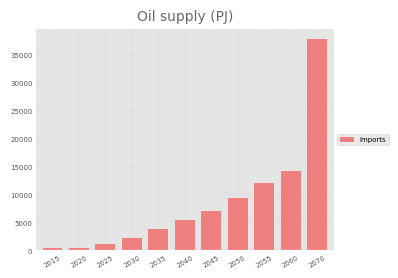

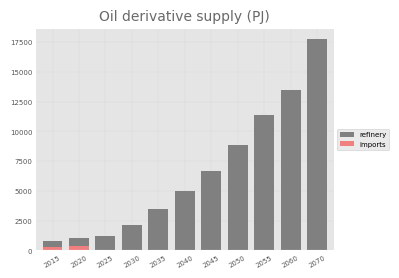

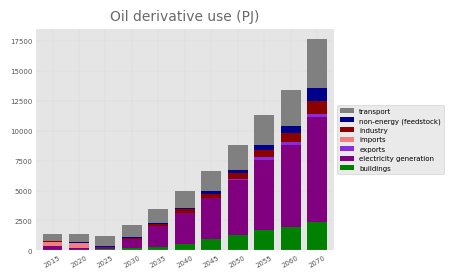

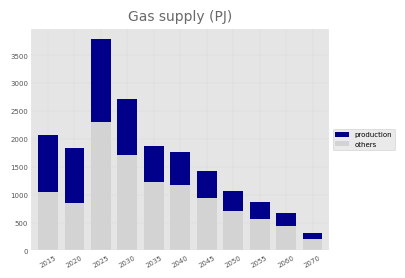

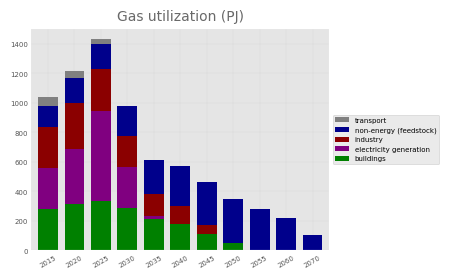

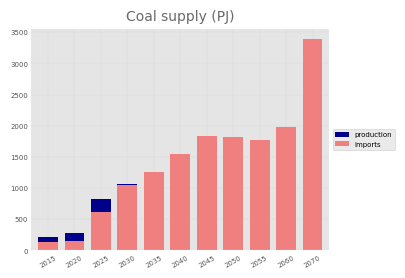

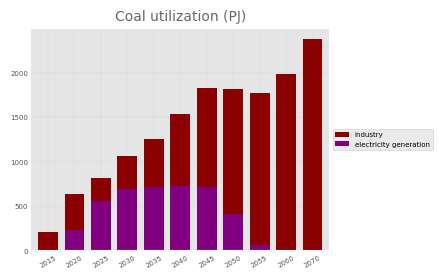

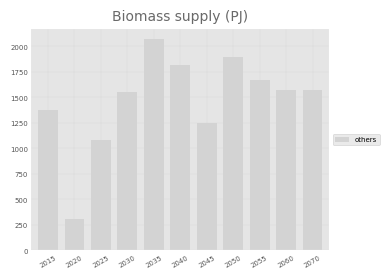

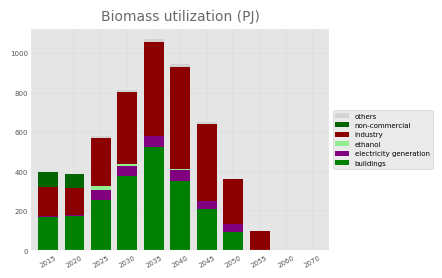

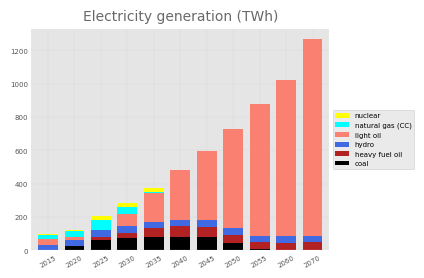

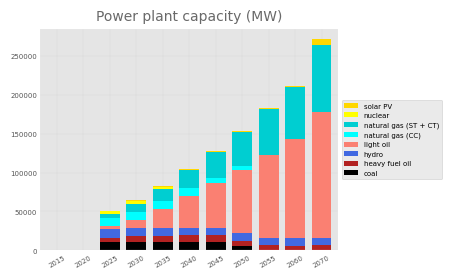

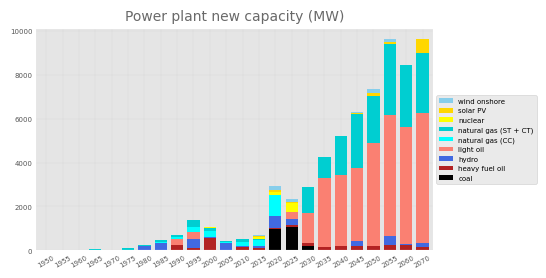

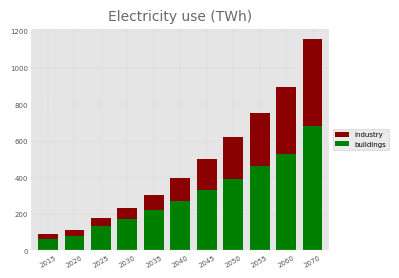

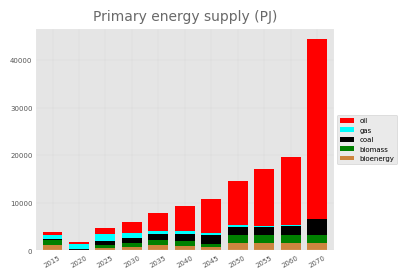

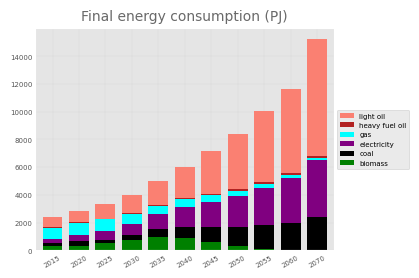

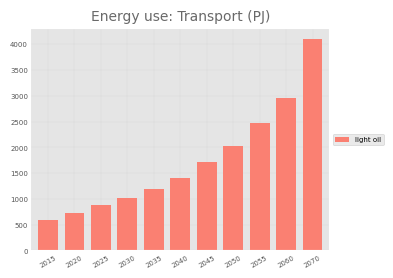

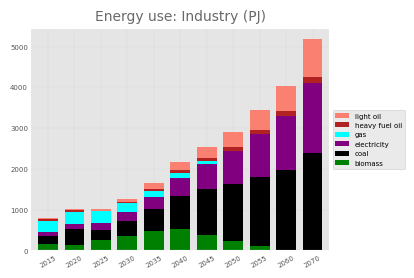

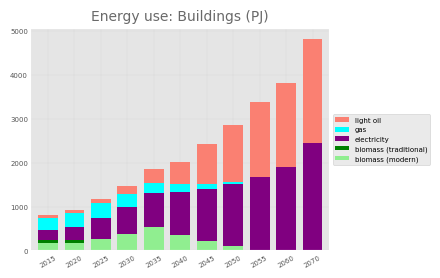

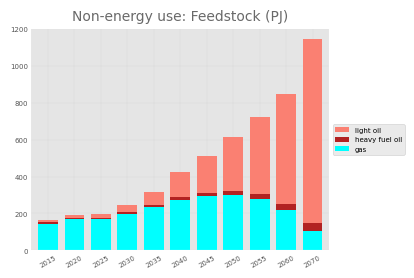

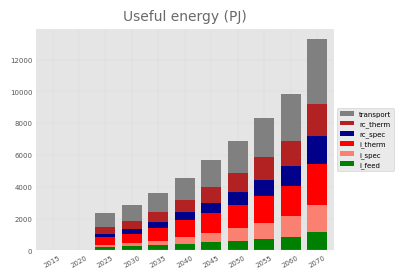

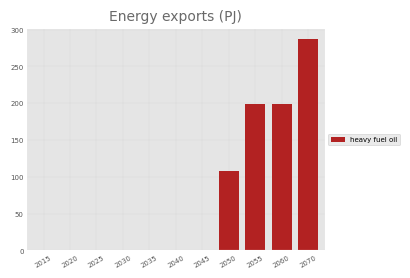

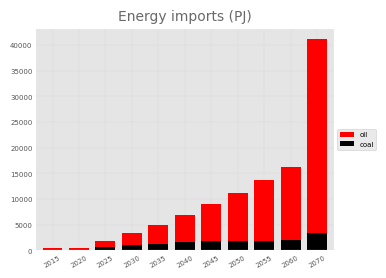

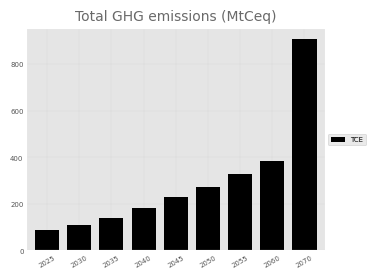

{'Electricity generation (TWh)':            coal  heavy fuel oil      hydro    light oil  natural gas (CC)  \
 2015   0.148044        0.000000  34.632660    35.362368         22.428041   
 2020  27.549324        0.000000  33.548172    17.195880         36.731689   
 2025  63.589903       15.787787  40.289285     0.000000         62.021842   
 2030  77.221656       30.023943  40.289285    71.258070         41.473382   
 2035  79.219856       52.480398  40.289285   173.716985          2.396052   
 2040  81.218056       63.055475  40.289285   294.693066          0.000000   
 2045  80.762536       61.672367  40.289285   415.645558          0.000000   
 2050  45.667786       48.144142  40.289285   593.001332          0.000000   
 2055   6.828912       41.956594  40.289285   787.767384          0.000000   
 2060   0.000000       46.323470  40.289285   934.971599          0.000000   
 2070   0.000000       48.984740  40.289285  1177.620174          0.000000   
 
         nuclear  
 2015   4.6

In [20]:
path = "D:\COMMITTED\Models\MESSAGEix-Pakistan-v2\output\plots"
plotter = plotter_MSG(scenario)
plotter.plotter(caseName, nodeloc=["R12_PAK"], path=path, yr_min=2015, yr_max=2070)

In [21]:
# close the connection to the database
new_mp.close_db() 